In [1]:
import pandas as pd
import os

# Folder containing the CSV files
results_folder = "../WMSLE/"  # Replace with the folder where the CSV files are stored

combined_df = pd.read_pickle(os.path.join(results_folder, "filtered_results.pkl"))

In [2]:
len(combined_df["train_r2"].unique())

540

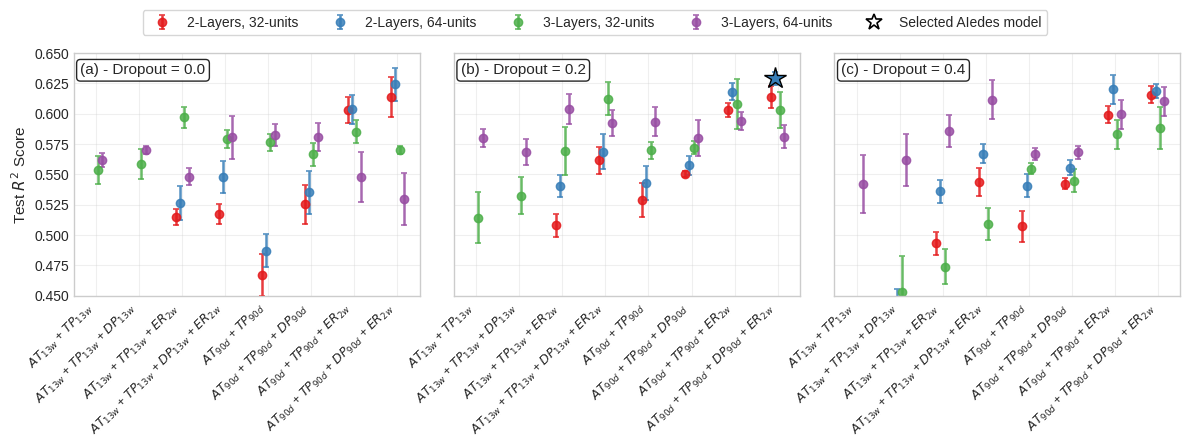

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

T2M = r'$AT_{90d}$'
T2M_WK = r'$AT_{13w}$'
T2M_MO = r'$T2M^{mo}$'
TP = r'$TP_{90d}$'
TP_WK = r'$TP_{13w}$'
D2M = r'$DP_{90d}$'
D2M_W = r'$DP_{13w}$'
R_T1 = r'$R_{t-1}$'
R_T2 = r'$R_{t-2}$'
ELR_WK = r'$ER_{2w}$'

variable_name_mapping = {
    'p1zn; p2zn': f'{ELR_WK}',
    't2m_mean_znorm; tp_sum_znorm': f'{T2M} + {TP}',
    't2m_mean_znorm(mean); tp_sum_znorm(mean)': f'{T2M_WK} + {TP_WK}',
    't2m_mean_znorm; tp_sum_znorm; p1zn; p2zn': f'{T2M} + {TP} + {ELR_WK}',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn': f'{T2M_WK} + {TP_WK} + {ELR_WK}',
    't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm': f'{T2M} + {TP} + {D2M}',
    't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean)': f'{T2M_WK} + {TP_WK} + {D2M_W}',
    't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm; p1zn; p2zn': f'{T2M} + {TP} + {D2M} + {ELR_WK}',
    't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn': f'{T2M_WK} + {TP_WK} + {D2M_W} + {ELR_WK}',
}

combined_df['input_variables_clean'] = combined_df['input_variables'].map(variable_name_mapping)

desired_order = [
    f'{T2M_WK} + {TP_WK}',
    f'{T2M_WK} + {TP_WK} + {D2M_W}',
    f'{T2M_WK} + {TP_WK} + {ELR_WK}',
    f'{T2M_WK} + {TP_WK} + {D2M_W} + {ELR_WK}',
    f'{T2M} + {TP}',
    f'{T2M} + {TP} + {D2M}',
    f'{T2M} + {TP} + {ELR_WK}',
    f'{T2M} + {TP} + {D2M} + {ELR_WK}',
]

grp = (
    combined_df
    .groupby(['dropout','input_variables_clean','num_layers','hidden_dim'])
    .test_r2
    .agg(['mean','sem'])
    .reset_index()
)
grp = grp[grp['input_variables_clean'].isin(desired_order)]

dropouts = sorted(grp['dropout'].unique())
ncol = len(dropouts)
fig, axes = plt.subplots(1, ncol, sharey=True, figsize=(4*ncol, 5))
colors = sns.color_palette("Set1", n_colors=4)

for ax, do in zip(axes, dropouts):
    sub = grp[grp['dropout']==do]
    layer_dim_combos = list(sub.groupby(['num_layers','hidden_dim']).groups.keys())
    for i, ((layers, dim), sub2) in enumerate(sub.groupby(['num_layers','hidden_dim'])):
        order_map = {v: idx for idx, v in enumerate(desired_order)}
        sub2 = sub2.assign(order=sub2['input_variables_clean'].map(order_map)).sort_values('order')
        n_groups = len(layer_dim_combos)
        displacement = (i - (n_groups-1)/2) * 0.1
        x = np.arange(len(sub2)) + displacement
        ax.errorbar(
            x, sub2['mean'], yerr=sub2['sem'],
            fmt='o',
            color=colors[i % len(colors)],
            label=f"{layers}-Layers, {dim}-units",
            capsize=2,
            capthick=1.2,
            linewidth=1.8,
            markersize=6,
            alpha=0.85
        )
    letter = chr(97 + dropouts.index(do))  # 'a', 'b', 'c', ...
    ordered_labels = [label for label in desired_order if label in sub['input_variables_clean'].values]
    ax.set_xticks(np.arange(len(ordered_labels)))
    ax.set_xticklabels(ordered_labels, rotation=45, ha='right', fontsize=9)
    ax.text(0.2, 0.9, f"({letter}) - Dropout = {do:.1f}",
            transform=ax.transAxes, fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.25", edgecolor='black', facecolor='white', alpha=0.85))
    ax.grid(True, alpha=0.3)
    if do == dropouts[0]:
        ax.set_ylabel(r'Test $R^2$ Score', fontsize=11)

# --- Highlight the chosen/best model ---------------------------------
CHOSEN = {
    "dropout": 0.2,   # <-- set your chosen dropout value
    "input_variables_clean": f'{T2M} + {TP} + {D2M} + {ELR_WK}',  # <-- set your chosen input set
    "num_layers": 2,  # <-- set layers of your chosen model
    "hidden_dim": 64  # <-- set hidden units of your chosen model
}

row_mask = (
    (grp["dropout"] == CHOSEN["dropout"]) &
    (grp["input_variables_clean"] == CHOSEN["input_variables_clean"]) &
    (grp["num_layers"] == CHOSEN["num_layers"]) &
    (grp["hidden_dim"] == CHOSEN["hidden_dim"])
)

if row_mask.any():
    y_mean = float(grp.loc[row_mask, "mean"].iloc[0])
    y_sem  = float(grp.loc[row_mask, "sem"].iloc[0])

    for ax, do in zip(axes, dropouts):
        if do != CHOSEN["dropout"]:
            continue

        sub = grp[grp["dropout"] == do]
        layer_dim_combos = list(sub.groupby(['num_layers','hidden_dim']).groups.keys())
        n_groups = len(layer_dim_combos)

        ordered_labels = [label for label in desired_order if label in sub['input_variables_clean'].values]
        x_col = ordered_labels.index(CHOSEN["input_variables_clean"])
        i_group = layer_dim_combos.index((CHOSEN["num_layers"], CHOSEN["hidden_dim"]))
        displacement = (i_group - (n_groups - 1)/2) * 0.1
        x_star = x_col + displacement

        # pick same color as its group
        chosen_color = colors[i_group % len(colors)]

        # draw as a star instead of a circle
        ax.errorbar(
            [x_star], [y_mean], yerr=[y_sem],
            fmt='*', markersize=16, linewidth=0, zorder=6,
            mfc=chosen_color, mec='black', mew=1.0,
            label="_nolegend_"
        )
        
# --- Legend: include the "Selected model" star (outline only) -------
from matplotlib.lines import Line2D

# star for legend only (outline, no fill)
star_handle = Line2D([], [], marker='*', linestyle='None',
                     markersize=12,
                     markerfacecolor='none',   # no fill
                     markeredgecolor='black',
                     markeredgewidth=1.2,
                     label='Selected AIedes model')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles + [star_handle],
    labels + ['Selected AIedes model'],
    loc='upper center',
    ncol=len(handles) + 1,
    frameon=True,
    fancybox=True,
    bbox_to_anchor=(0.5, 0.9)
)
plt.ylim(0.45, 0.65)
plt.tight_layout()
plt.subplots_adjust(top=0.80, wspace=0.1)  # leave space for the legend
savefig = os.path.join("./", "./nn_results_by_dropout.pdf")
plt.savefig(savefig, bbox_inches='tight', dpi=300)
plt.show()


In [4]:
import pandas as pd

# 1) Compute summary statistics for each configuration
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse'
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
    .groupby(['input_variables_clean', 'dropout', 'num_layers', 'hidden_dim'])
    .agg(agg_funcs)
)

# 2) Flatten the MultiIndex columns
summary_df.columns = [
    '_'.join(col).strip() for col in summary_df.columns.values
]
summary_df = summary_df.reset_index()

# 3) (Optional) display the full summary
#display(summary_df)
# 4) Select the top 5 configurations by mean R²
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5)
# 5) Display the top 5 configurations
top5.to_csv(os.path.join("./", "nn_top5_by_dropout.csv"), index=False)
display(top5)

,input_variables_clean,dropout,num_layers,hidden_dim,test_r2_mean,test_r2_sem,test_loss_mean,test_loss_sem,test_binary_accuracy_mean,test_binary_accuracy_sem,test_rmse_mean,test_rmse_sem
77,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.2,2,64,0.629114,0.005494,0.589055,0.023125,0.918519,0.002256,22.551855,1.245053
73,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.0,2,64,0.624149,0.013461,0.617523,0.045787,0.919493,0.001094,23.451820,1.932154
93,$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$,0.4,2,64,0.620113,0.011880,0.557446,0.023372,0.922807,0.001286,22.797226,1.227576
81,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.4,2,64,0.618669,0.006034,0.596264,0.037831,0.921442,0.001813,22.869044,1.272534
89,$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$,0.2,2,64,0.618208,0.006794,0.598748,0.042082,0.921442,0.002339,22.912792,1.412412


In [5]:
import pandas as pd

# 1) Aggregate means & SEMs
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse',
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
      .groupby(['input_variables', 'dropout', 'num_layers', 'hidden_dim'])
      .agg(agg_funcs)
)

# flatten the MultiIndex cols
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# 2) Pick top‐5 by mean R²
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5)

# 3) Map Variables → compact LaTeX
latex_name_map = {
    # use exactly the strings that appear in input_variables_clean
    't2m_mean_znorm; tp_sum_znorm; d2m_mean_znorm; p1zn; p2zn':
        r'$T2M + TP + D2M + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); d2m_mean_znorm(mean); p1zn; p2zn':
        r'$T2M^{wk} + TP^{wk} + D2M^{wk} + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm; tp_sum_znorm':
        r'$T2M + TP$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean)':
        r'$T2M^{wk} + TP^{wk}$',
    't2m_mean_znorm; tp_sum_znorm; p1zn; p2zn':
        r'$T2M + TP + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn':
        r'$T2M^{wk} + TP^{wk} + R_{t-1} + R_{t-2}$',
}

top5['Variables'] = top5['input_variables'].map(latex_name_map)

# 4) Define your formatter for mean ± SE
def fmt_mean_sem(mean, sem, sig_digits=2):
    """
    Format mean ± sem:
      - sem rounded to specified significant digits, no scientific notation
      - mean shown with matching decimals (fixed-point)
    """
    import math
    import numpy as np
    if sem == 0 or np.isnan(sem):
        return rf"${mean:.3f}\pm{sem:.2f}$"
    
    # Calculate decimals based on significant digits
    exp = int(math.floor(math.log10(abs(sem))))
    decimals = -exp + (sig_digits - 1)
    
    sem_rounded = round(sem, decimals)
    mean_rounded = round(mean, decimals)
    
    if decimals > 0:
        fmt = f"{{0:.{decimals}f}}"
        mean_str = fmt.format(mean_rounded)
        sem_str = fmt.format(sem_rounded)
    elif decimals == 0:
        mean_str = f"{int(round(mean_rounded))}"
        sem_str = f"{int(round(sem_rounded))}"
    else:
        # decimals < 0: round to 10s, 100s, etc.
        factor = 10**(-decimals)
        mean_str = f"{int(round(mean_rounded/factor)*factor)}"
        sem_str = f"{int(round(sem_rounded/factor)*factor)}"
    
    return rf"${mean_str}\pm{sem_str}$"

# 5) Build new "pm" columns
for metric, label in [
    ('test_r2',             'R^2'),
    ('test_loss',           'Loss'),
    ('test_binary_accuracy','Acc'),
    ('test_rmse',           'RMSE'),
]:
    m_mean = f"{metric}_mean"
    m_sem  = f"{metric}_sem"
    col_pm = f"{label}_pm"
    top5[col_pm] = top5.apply(
        lambda row: fmt_mean_sem(row[m_mean], row[m_sem]),
        axis=1
    )

# 6) Assemble the final table
final = top5[[
    'Variables', 'dropout', 'num_layers', 'hidden_dim',
    'R^2_pm', 'Loss_pm', 'Acc_pm', 'RMSE_pm'
]].rename(columns={
    'dropout':'Drop',
    'num_layers':'Lay',
    'hidden_dim':'HU',
    'R^2_pm':r'$R^2\pm SE$',
    'Loss_pm':r'$\overline{Loss}\pm SE$',
    'Acc_pm':r'$\overline{Acc}\pm SE$',
    'RMSE_pm':r'$\overline{RMSE}\pm SE$',
})

# 7) Set up formatting for the three numeric config columns
fmt = {
    'Drop': lambda x: f"{x:.2g}",
    'Lay':  lambda x: f"{int(x)}",
    'HU':   lambda x: f"{int(x)}",
}

# 8) Emit LaTeX
print(final.to_latex(
    index=False,
    escape=False,
    caption=r"Top 5 Model Configurations by Test $R^2$",
    label="tab:top5models",
    column_format='lrrr' + 'r'*(len(final.columns)-4),
    formatters=fmt
))


\begin{table}
\caption{Top 5 Model Configurations by Test $R^2$}
\label{tab:top5models}
\begin{tabular}{lrrrrrrr}
\toprule
Variables & Drop & Lay & HU & $R^2\pm SE$ & $\overline{Loss}\pm SE$ & $\overline{Acc}\pm SE$ & $\overline{RMSE}\pm SE$ \\
\midrule
NaN & 0.2 & 2 & 64 & $0.6291\pm0.0055$ & $0.589\pm0.023$ & $0.9185\pm0.0023$ & $22.6\pm1.2$ \\
NaN & 0 & 2 & 64 & $0.624\pm0.013$ & $0.618\pm0.046$ & $0.9195\pm0.0011$ & $23.5\pm1.9$ \\
$T2M + TP + R_{t-1} + R_{t-2}$ & 0.4 & 2 & 64 & $0.620\pm0.012$ & $0.557\pm0.023$ & $0.9228\pm0.0013$ & $22.8\pm1.2$ \\
NaN & 0.4 & 2 & 64 & $0.6187\pm0.0060$ & $0.596\pm0.038$ & $0.9214\pm0.0018$ & $22.9\pm1.3$ \\
$T2M + TP + R_{t-1} + R_{t-2}$ & 0.2 & 2 & 64 & $0.6182\pm0.0068$ & $0.599\pm0.042$ & $0.9214\pm0.0023$ & $22.9\pm1.4$ \\
\bottomrule
\end{tabular}
\end{table}



In [6]:
# Get the best performing configuration (highest test_r2_mean)
best_config = summary_df.loc[summary_df['test_r2_mean'].idxmax()]

print("Best performing configuration:")
print(f"Input variables: {best_config['input_variables']}")
print(f"Dropout: {best_config['dropout']}")
print(f"Num layers: {best_config['num_layers']}")
print(f"Hidden dim: {best_config['hidden_dim']}")
print(f"Mean R²: {best_config['test_r2_mean']:.6f}")
print(f"SEM R²: {best_config['test_r2_sem']:.6f}")

# Filter combined_df to get all instances with this configuration
best_instances = combined_df[
    (combined_df['input_variables'] == best_config['input_variables']) &
    (combined_df['dropout'] == best_config['dropout']) &
    (combined_df['num_layers'] == best_config['num_layers']) &
    (combined_df['hidden_dim'] == best_config['hidden_dim'])
]

print(f"\nFound {len(best_instances)} instances with this configuration")

# Calculate absolute difference from mean for each instance
mean_r2 = best_config['test_r2_mean']
best_instances_copy = best_instances.copy()
best_instances_copy['abs_diff_from_mean'] = abs(best_instances_copy['test_r2'] - mean_r2)

# Find the random state closest to the mean
closest_to_mean = best_instances_copy.loc[best_instances_copy['abs_diff_from_mean'].idxmin()]

print(f"\nRandom state closest to mean:")
print(f"Random state: {closest_to_mean['random_state']}")
print(f"Test R²: {closest_to_mean['test_r2']:.6f}")
print(f"Difference from mean: {closest_to_mean['abs_diff_from_mean']:.6f}")

# Show all instances sorted by closeness to mean
print(f"\nAll instances sorted by closeness to mean:")
display(best_instances_copy[['random_state', 'test_r2', 'abs_diff_from_mean']].sort_values('abs_diff_from_mean'))

Best performing configuration:
Input variables: t2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm; p1zn; p2zn
Dropout: 0.2
Num layers: 2
Hidden dim: 64
Mean R²: 0.629114
SEM R²: 0.005494

Found 5 instances with this configuration

Random state closest to mean:
Random state: 14
Test R²: 0.631491
Difference from mean: 0.002377

All instances sorted by closeness to mean:


,random_state,test_r2,abs_diff_from_mean
231,14,0.631491,0.002377
232,15,0.620613,0.008501
233,17,0.638139,0.009025
234,3,0.642500,0.013385
230,10,0.612829,0.016286


In [7]:
best_instances_copy

,model_type,loss_type,hidden_dim,num_layers,dropout,num_epochs,learning_rate,batch_size,random_state,nonzero_weight,...,train_FPR_end,test_FPR_end,train_FNR_end,test_FNR_end,train_TPR_end,test_TPR_end,train_TNR_end,test_TNR_end,input_variables_clean,abs_diff_from_mean
230,positive_ff,FrequencyWeightedMSLE,64,2,0.2,3000,0.001,64,10,0.799415,...,0.051189,0.051341,0.036817,0.158738,0.963183,0.841262,0.948811,0.948659,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.016286
231,positive_ff,FrequencyWeightedMSLE,64,2,0.2,3000,0.001,64,14,0.799415,...,0.049817,0.069146,0.045079,0.123301,0.954921,0.876699,0.950183,0.930854,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.002377
232,positive_ff,FrequencyWeightedMSLE,64,2,0.2,3000,0.001,64,15,0.799415,...,0.051311,0.075854,0.042649,0.110680,0.957351,0.889320,0.948689,0.924146,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.008501
233,positive_ff,FrequencyWeightedMSLE,64,2,0.2,3000,0.001,64,17,0.799415,...,0.049238,0.074024,0.045565,0.116019,0.954435,0.883981,0.950762,0.925976,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.009025
234,positive_ff,FrequencyWeightedMSLE,64,2,0.2,3000,0.001,64,3,0.799415,...,0.054787,0.064512,0.039368,0.155340,0.960632,0.844660,0.945213,0.935488,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.013385


In [8]:
import glob

# Get the best performing configuration from your previous analysis
best_config = summary_df.loc[summary_df['test_r2_mean'].idxmax()]

# Extract the parameters
model_type = "positive_ff"  # From your data
loss_type = "FrequencyWeighted"  # From your data
hidden_dim = int(best_config['hidden_dim'])
num_layers = int(best_config['num_layers'])
dropout = best_config['dropout']
learning_rate = "5e-05"  # From your data (appears to be consistent)
batch_size = 64  # From your data (appears to be consistent)
random_state = closest_to_mean['random_state']  # You'll need to specify which random state you want
input_variables = best_config['input_variables']

# Clean the input_variables string to match filename format
# Replace special characters and spaces that might be in filenames
input_vars_clean = input_variables.replace(';', '+').replace(' ', '').replace('(', '').replace(')', '').replace(',', '')

# Construct the filename
filename = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_dim}_lay{num_layers}_do{dropout}_lr{learning_rate}_bs{batch_size}_sd{random_state}_{input_vars_clean}_results.pkl"

print("Best configuration parameters:")
print(f"Hidden dim: {hidden_dim}")
print(f"Num layers: {num_layers}")
print(f"Dropout: {dropout}")
print(f"Input variables: {input_variables}")
print(f"\nConstructed filename:")
print(filename)

# Full path to the file
results_folder = "./MSE/"
full_path = os.path.join(results_folder, filename)
print(f"\nFull path:")
print(full_path)

# Check if file exists
if os.path.exists(full_path):
    print(f"\n✓ File exists!")
else:
    print(f"\n✗ File not found. You may need to adjust the filename format.")
    # Let's also try to find similar files
    pattern = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_dim}_lay{num_layers}_do{dropout}*.pkl"
    similar_files = glob.glob(os.path.join(results_folder, pattern))
    if similar_files:
        print("Similar files found:")
        for f in similar_files:
            print(f"  {os.path.basename(f)}")

Best configuration parameters:
Hidden dim: 64
Num layers: 2
Dropout: 0.2
Input variables: t2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm; p1zn; p2zn

Constructed filename:
modelpositive_ff_lossFrequencyWeighted_hid64_lay2_do0.2_lr5e-05_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl

Full path:
./MSE/modelpositive_ff_lossFrequencyWeighted_hid64_lay2_do0.2_lr5e-05_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl

✗ File not found. You may need to adjust the filename format.


In [9]:
import pandas as pd
import numpy as np

# --- 1) Aggregate means & SEMs ---
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse',   # adjust if your RMSE column is named differently
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
      .groupby(['input_variables_clean', 'dropout', 'num_layers', 'hidden_dim'])
      .agg(agg_funcs)
)

# flatten the MultiIndex cols
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# --- 2) Pick top-5 by mean R² ---
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5).copy()

# --- 3) Format Variables: replace " + " with $\,\text{+}\,$ so \text lives in math mode ---
top5['input_variables_clean'] = (
    top5['input_variables_clean'].str.replace(' + ', r'\,\text{+}\,', regex=False)
)

# --- 4) Build "mean \pm sem" strings for each metric and drop SEM columns ---
def fmt_pm(mean, sem, ndigits=3):
    return rf"${mean:.{ndigits}f} \pm {sem:.{ndigits}f}$"

top5['R^2']  = [fmt_pm(m, s, 3) for m, s in zip(top5['test_r2_mean'],               top5['test_r2_sem'])]
top5['Loss'] = [fmt_pm(m, s, 3) for m, s in zip(top5['test_loss_mean'],             top5['test_loss_sem'])]
top5['Acc']  = [fmt_pm(m, s, 3) for m, s in zip(top5['test_binary_accuracy_mean'],  top5['test_binary_accuracy_sem'])]
top5['RMSE'] = [fmt_pm(m, s, 1) for m, s in zip(top5['test_rmse_mean'],         top5['test_rmse_sem'])]  # 1 decimal for RMSE, tweak if you like

# --- 5) Select & rename columns for LaTeX ---
latex_df = top5.rename(columns={
    'input_variables_clean': 'Variables',
    'dropout': 'DO',
    'num_layers': 'Lay',
    'hidden_dim': 'HU',
})[['Variables', 'DO', 'Lay', 'HU', 'R^2', 'Loss', 'Acc', 'RMSE']]

# --- 6) Emit LaTeX ---
print(latex_df.to_latex(
    index=False,
    escape=False,  # keep $...$ and \text{+}
    caption=r"Top 5 Model Configurations by Test $R^2$",
    label="tab:top5models",
    # l for Variables, r for the rest
    column_format='l' + 'r'*(latex_df.shape[1]-1)
))


\begin{table}
\caption{Top 5 Model Configurations by Test $R^2$}
\label{tab:top5models}
\begin{tabular}{lrrrrrrr}
\toprule
Variables & DO & Lay & HU & R^2 & Loss & Acc & RMSE \\
\midrule
$AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$DP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.200000 & 2 & 64 & $0.629 \pm 0.005$ & $0.589 \pm 0.023$ & $0.919 \pm 0.002$ & $22.6 \pm 1.2$ \\
$AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$DP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.000000 & 2 & 64 & $0.624 \pm 0.013$ & $0.618 \pm 0.046$ & $0.919 \pm 0.001$ & $23.5 \pm 1.9$ \\
$AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.400000 & 2 & 64 & $0.620 \pm 0.012$ & $0.557 \pm 0.023$ & $0.923 \pm 0.001$ & $22.8 \pm 1.2$ \\
$AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$DP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.400000 & 2 & 64 & $0.619 \pm 0.006$ & $0.596 \pm 0.038$ & $0.921 \pm 0.002$ & $22.9 \pm 1.3$ \\
$AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.200000 & 2 & 64 & $0.618 \pm 0.007$ & $0.599 \pm 0.042$ & $0.921 \pm 0.00